In [2]:
from eib import *

/tmp/ipykernel_3617/57604110.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")


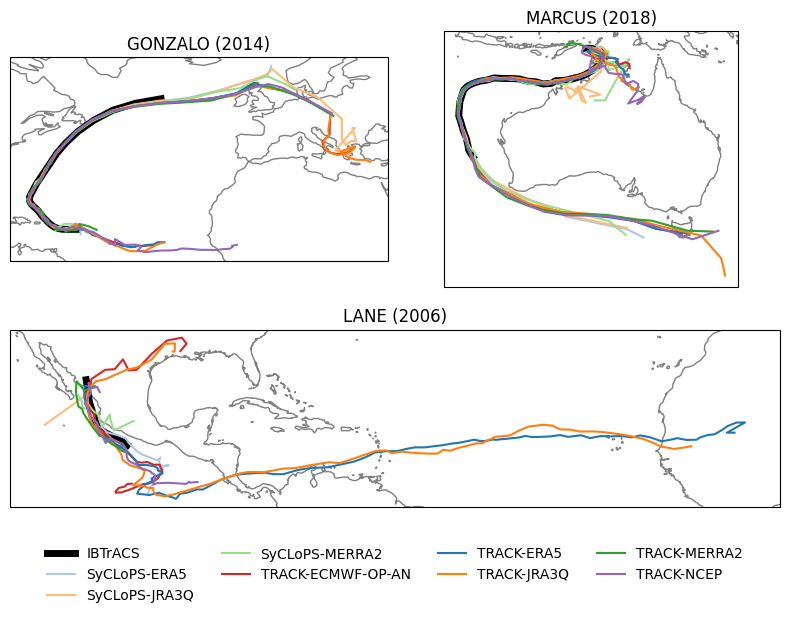

In [2]:
examples = {
    "GONZALO": {"name":"GONZALO", "year":2014, "basin":"NA"},
    "LANE": {"name":"LANE", "year":2006, "basin":"EP"},
    "MARCUS": {"name":"MARCUS", "year":2018, "basin":"SI"},
}

fig = plt.figure(figsize=(8,6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top row: GONZALO and MARCUS side by side
ax_gonzalo = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_marcus  = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
# Bottom row: LANE spanning full width
ax_lane    = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())

ax_map = {
    "GONZALO": ax_gonzalo,
    "LANE": ax_lane,
    "MARCUS": ax_marcus,
}

handles_dict = {}
for e in examples:
    ex = examples[e]
    # Load eib
    b = ex["basin"]
    eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")
    # Choose cyclone
    NAME, SEASON = ex["name"], ex["year"]
    # Extract data for given cyclone
    TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
    TRACK_ib = TRACK.sel(source="IBTrACS").where(~np.isnan(TRACK.sel(source="IBTrACS").lon), drop = True)

    ax = ax_map[e]
    for ds in TRACK.source.values:
        K = TRACK.sel(source = ds).squeeze()
        if (~np.isnan(K.lon)).sum() > 0:
            mask = ~np.isnan(K.lon) & ~np.isnan(K.lat)
            lon = K.lon[mask]
            lat = K.lat[mask]
            # Plot trajectory
            lw = 5 if ds == 'IBTrACS' else None
            line, = ax.plot(lon, lat,
                    color = PALETTE[ds], lw = lw, label = ds,
                   transform = ccrs.PlateCarree())
            if ds not in handles_dict:
                handles_dict[ds] = line
    ax.coastlines(color = "grey")
    ax.set_title(NAME+" ("+str(SEASON)+")")

plt.tight_layout()

# Build the legend below all panels, constrained to LANE's panel width
handles = list(handles_dict.values())
labels  = list(handles_dict.keys())

# Determine how many columns fit within LANE's panel width
# Get LANE panel width in figure coordinates
lane_bbox = ax_lane.get_position()
lane_width_fig = lane_bbox.width  # in figure fraction

# Try increasing ncol until the legend would exceed LANE's width
best_ncol = 1
for ncol in range(1, len(labels) + 1):
    leg = fig.legend(handles, labels, loc='center', ncol=ncol,
                     bbox_to_anchor=(0.5, 0), frameon=False)
    fig.canvas.draw_idle()
    renderer = fig.canvas.get_renderer()
    leg_bbox = leg.get_window_extent(renderer)
    leg_width_fig = leg_bbox.width / fig.get_window_extent(renderer).width
    leg.remove()
    if leg_width_fig <= lane_width_fig:
        best_ncol = ncol
    else:
        break

# Place the final legend
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 0.1), ncol=best_ncol, frameon=False)

plt.subplots_adjust(bottom=0.08)

plt.savefig("examples_matching.png", bbox_inches = "tight")

/tmp/ipykernel_628/3543143389.py:27: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")


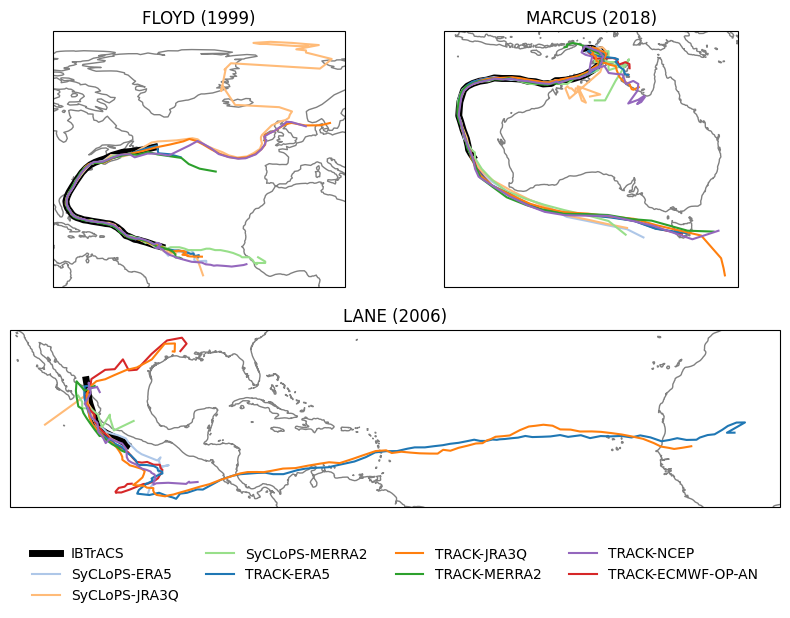

In [3]:
examples = {
    "FLOYD": {"name":"FLOYD", "year":1999, "basin":"NA"},
    "LANE": {"name":"LANE", "year":2006, "basin":"EP"},
    "MARCUS": {"name":"MARCUS", "year":2018, "basin":"SI"},
}

fig = plt.figure(figsize=(8,6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top row: FLOYD and MARCUS side by side
ax_FLOYD = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_marcus  = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
# Bottom row: LANE spanning full width
ax_lane    = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())

ax_map = {
    "FLOYD": ax_FLOYD,
    "LANE": ax_lane,
    "MARCUS": ax_marcus,
}

handles_dict = {}
for e in examples:
    ex = examples[e]
    # Load eib
    b = ex["basin"]
    eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")
    # Choose cyclone
    NAME, SEASON = ex["name"], ex["year"]
    # Extract data for given cyclone
    TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
    TRACK_ib = TRACK.sel(source="IBTrACS").where(~np.isnan(TRACK.sel(source="IBTrACS").lon), drop = True)

    ax = ax_map[e]
    for ds in TRACK.source.values:
        K = TRACK.sel(source = ds).squeeze()
        if (~np.isnan(K.lon)).sum() > 0:
            mask = ~np.isnan(K.lon) & ~np.isnan(K.lat)
            lon = K.lon[mask]
            lat = K.lat[mask]
            # Plot trajectory
            lw = 5 if ds == 'IBTrACS' else None
            line, = ax.plot(lon, lat,
                    color = PALETTE[ds], lw = lw, label = ds,
                   transform = ccrs.PlateCarree())
            if ds not in handles_dict:
                handles_dict[ds] = line
    ax.coastlines(color = "grey")
    ax.set_title(NAME+" ("+str(SEASON)+")")

plt.tight_layout()

# Build the legend below all panels, constrained to LANE's panel width
handles = list(handles_dict.values())
labels  = list(handles_dict.keys())

# Determine how many columns fit within LANE's panel width
# Get LANE panel width in figure coordinates
lane_bbox = ax_lane.get_position()
lane_width_fig = lane_bbox.width  # in figure fraction

# Try increasing ncol until the legend would exceed LANE's width
best_ncol = 1
for ncol in range(1, len(labels) + 1):
    leg = fig.legend(handles, labels, loc='center', ncol=ncol,
                     bbox_to_anchor=(0.5, 0), frameon=False)
    fig.canvas.draw_idle()
    renderer = fig.canvas.get_renderer()
    leg_bbox = leg.get_window_extent(renderer)
    leg_width_fig = leg_bbox.width / fig.get_window_extent(renderer).width
    leg.remove()
    if leg_width_fig <= lane_width_fig:
        best_ncol = ncol
    else:
        break

# Place the final legend
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 0.1), ncol=best_ncol, frameon=False)

plt.subplots_adjust(bottom=0.08)

#plt.savefig("examples_matching.png", bbox_inches = "tight")

In [5]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs

def plot_one_cyclone_panel(
    ax,
    *,
    name: str,
    year: int,
    basin: str,
    palette: dict,
    eib_dir: str = "../extended-ibtracs",
    add_coastlines: bool = True,
    add_title: bool = True,
    handles_dict: dict | None = None,
):
    """
    Draw a single cyclone track panel on `ax` (a Cartopy GeoAxes).

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxesSubplot
        Axis to draw into (created with projection=ccrs.PlateCarree()).
    name, year, basin : str, int, str
        Cyclone identifier and basin (e.g., 'NA', 'EP', 'SI').
    palette : dict
        Mapping {source_name: color}. Must include the sources present in the dataset.
    eib_dir : str
        Directory containing extended-ibtracs_{basin}.nc files.
    handles_dict : dict | None
        If provided, gets populated with one Line2D per source (for a shared legend),
        but only the first time each source is seen. If None, a new dict is used.

    Returns
    -------
    handles_dict : dict
        Mapping {source_name: Line2D}, suitable for building a legend.
    track : xarray.Dataset
        The cyclone subset (all sources).
    track_ib : xarray.Dataset
        The IBTrACS-only subset with valid lon/lat (kept for parity with your original code).
    """
    if handles_dict is None:
        handles_dict = {}

    # Load extended IBTrACS for this basin
    eib_path = f"{eib_dir}/extended-ibtracs_{basin}.nc"
    eib = xr.open_dataset(eib_path)

    # Extract data for given cyclone
    track = eib.where((eib.name == name) & (eib.time.dt.year == year), drop=True)
    track_ib = (
        track.sel(source="IBTrACS")
        .where(~np.isnan(track.sel(source="IBTrACS").lon), drop=True)
    )

    # Plot all sources present
    for ds in track.source.values:
        k = track.sel(source=ds).squeeze()

        if (~np.isnan(k.lon)).sum() > 0:
            mask = ~np.isnan(k.lon) & ~np.isnan(k.lat)
            lon = k.lon[mask]
            lat = k.lat[mask]

            lw = 5 if ds == "IBTrACS" else None
            line, = ax.plot(
                lon,
                lat,
                color=palette[ds],
                lw=lw,
                label=ds,
                transform=ccrs.PlateCarree(),
            )

            if ds not in handles_dict:
                handles_dict[ds] = line

    if add_coastlines:
        ax.coastlines(color="grey")
    if add_title:
        ax.set_title(f"{name} ({year})")

    return handles_dict, track, track_ib

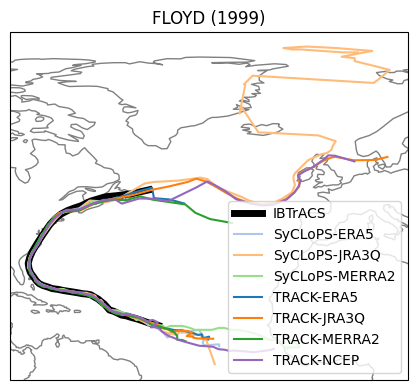

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

handles_dict, track, track_ib = plot_one_cyclone_panel(
    ax,
    name="FLOYD",
    year=1999,
    basin="NA",
    palette=PALETTE,
)

ax.legend(handles_dict.values(), handles_dict.keys(), frameon=True)
plt.tight_layout()